# **Experiment Notebook**



In [1]:
# Do not modify this code
%pip install -q utstd

from utstd.ipyrenders import *

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [136]:
# Core
import os, json, math, warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Dict
from joblib import dump

import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, roc_auc_score,
    precision_recall_fscore_support, classification_report, RocCurveDisplay
)
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import calibration_curve


# Your package (from TestPyPI)
from amla_at1.data.openmeteo import fetch_daily_archive, make_supervised_tables
from amla_at1.data.time_split import split_by_date
from amla_at1.features.weather import clip_and_fill, normalize_cols
from amla_at1.models.metrics_extra import cls_scores
from amla_at1.models.export import save_model
from amla_at1.data import save_sets

warnings.filterwarnings("ignore")

# Project paths
ROOT = Path.cwd().resolve()
DATA_DIR = (ROOT / "../data").resolve()
RAW_DIR = DATA_DIR / "raw"
PROC_DIR = DATA_DIR / "processed"
MODELS_DIR = ROOT / "models"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

from packaging import version
import sklearn

tree = DecisionTreeClassifier(max_depth=2, random_state=42)

if version.parse(sklearn.__version__) >= version.parse("1.4"):
    ada = AdaBoostClassifier(estimator=tree, n_estimators=150, learning_rate=0.2, random_state=42)
else:
    ada = AdaBoostClassifier(base_estimator=tree, n_estimators=150, learning_rate=0.2, random_state=42)

@dataclass
class _Artifacts:
    folder_path: Path = PROC_DIR
at = _Artifacts()

---
## A. Project Description


In [6]:
# <Student to fill this section>
student_name = "Nayna Jahan Neha"
student_id = "25238736"

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [8]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Business Understanding

In [154]:
# <Student to fill this section>
business_use_case_description = """
The goal is to deliver an API that returns a calibrated probability P(rain in exactly 7 days) for Sydney, so customers (events, construction, logistics, field ops) can make weekly plan/roster decisions, allocate resources, and schedule contingencies.
Hypothesis: using recent weather regimes (rolling windows) + seasonality to predict P(rain+7d) will outperform simple climatology and enable users to reduce weather-related costs (missed work, asset damage, wasted prep) and improve on-time delivery versus current planning heuristics.

"""

In [155]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [156]:
# <Student to fill this section>
business_objectives = """
Impact of accuracy: well-calibrated probabilities let clients set thresholds tuned to their cost ratio, reducing unnecessary reschedules (when dry) and preventing high-cost rain surprises. Benefits: lower operational cost/penalties, fewer cancellations, safer worksites, higher customer satisfaction.
Impact of errors: false positives (predict rain but dry) → avoidable prep/reschedule cost and alarm fatigue; false negatives (predict dry but rains) → higher losses: delays, damage, safety risk, refunds. Under/over-confident probabilities mis-set thresholds and amplify both costs. Therefore we prioritize calibration (Brier/RMSE/MAE) plus adequate discrimination (ROC/PR), monitor drift, and retrain/ recalibrate to keep business decisions reliable.
"""

In [157]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [158]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
This project exposes as an API returning calibrated P(rain in 7 days) plus guidance on thresholds, that can be consumed in weekly planning dashboards, job scheduling, and automated alerts. It can be used to trigger contingency playbooks (tarping, resourcing, venue changes).

Primary users: Operations planners (events, construction, logistics), site managers, schedulers/dispatch, and product teams integrating the API into client apps.

Impacted parties: Field crews and contractors (rosters/safety), inventory and transport teams (equipment allocation, delivery timing), finance (costs/penalties), end customers/attendees (service quality), and compliance/safety teams (risk reduction).

Expectations: Reliable uptime, stable schema, well-calibrated probabilities, transparent versioning, and documented thresholds by cost scenario. Regular drift monitoring, seasonal performance reports, and retraining when KPIs degrade.
"""

In [159]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [9]:
START_DATE = "2010-01-01"
END_DATE   = "2024-12-31"
DAILY_CACHE = RAW_DIR / f"sydney_daily_{START_DATE}_{END_DATE}.csv"

if DAILY_CACHE.exists():
    daily = pd.read_csv(DAILY_CACHE, parse_dates=["date"])
    daily["date"] = daily["date"].dt.date
    daily = daily.set_index("date").sort_index()
else:
    daily = fetch_daily_archive(start_date=START_DATE, end_date=END_DATE)
    daily.reset_index().to_csv(DAILY_CACHE, index=False)

daily.head(), daily.shape

(            weather_code  temperature_2m_max  temperature_2m_min  \
 date                                                               
 2010-01-01            53                25.7                21.1   
 2010-01-02            63                26.9                21.0   
 2010-01-03            51                20.6                19.5   
 2010-01-04            51                22.5                19.2   
 2010-01-05             3                26.0                18.6   
 
             apparent_temperature_max  apparent_temperature_min  \
 date                                                             
 2010-01-01                      26.7                      24.2   
 2010-01-02                      32.6                      22.2   
 2010-01-03                      21.3                      19.2   
 2010-01-04                      22.3                      19.5   
 2010-01-05                      30.0                      19.8   
 
             precipitation_sum  rain_sum  sn

In [14]:
daily.columns          
list(daily.columns)       
daily.columns.tolist()     

['weather_code',
 'temperature_2m_max',
 'temperature_2m_min',
 'apparent_temperature_max',
 'apparent_temperature_min',
 'precipitation_sum',
 'rain_sum',
 'snowfall_sum',
 'precipitation_hours',
 'sunshine_duration',
 'daylight_duration',
 'wind_speed_10m_max',
 'wind_gusts_10m_max',
 'wind_direction_10m_dominant',
 'shortwave_radiation_sum',
 'et0_fao_evapotranspiration']

### C.2 Define Target variable

In [ ]:
target_variable = "will_rain_in_7_days"

In [15]:
target_definition_explanations = """
The target `will_rain_in_7_days` is a binary label where, for a given day D, `will_rain_in_7_days = True` if the daily `rain_sum` on D+7 is > 0 mm, else False. It provide a clear yes/no answer for Sydney exactly 7 days ahead so customers can make go/no-go decisions (events, staffing, logistics). For each day D, will_rain_in_7_days = True will be set iff daily.rain_sum at D+7 > 0.0 mm; else False. The API’s rain_sum (liquid precipitation only) has been used to match the requirement of ‘rain (not total precipitation)’. A single fixed horizon simplifies training, evaluation, and API behavior for users.
"""

In [16]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [17]:
# Supervised tables using package helper
X_cls, y_cls, X_reg_unused, y_reg_unused = make_supervised_tables(
    daily_df=daily,
    rain_label_lag_days=7,    
    precip_window_days=3,     
    feature_lookback_days=14  
)

df_cls = X_cls.copy()
df_cls["will_rain_in_7_days"] = y_cls.astype(int)
df_cls.head(), df_cls.shape, df_cls["will_rain_in_7_days"].mean()

(            temperature_2m_max_mean_14  temperature_2m_max_std_14  \
 date                                                                
 2010-01-03                   24.400000                   3.345146   
 2010-01-04                   23.925000                   2.891799   
 2010-01-05                   24.340000                   2.670768   
 2010-01-06                   24.400000                   2.393324   
 2010-01-07                   24.214286                   2.239366   
 
             temperature_2m_max_sum_14  temperature_2m_min_mean_14  \
 date                                                                
 2010-01-03                       73.2                   20.533333   
 2010-01-04                       95.7                   20.200000   
 2010-01-05                      121.7                   19.880000   
 2010-01-06                      146.4                   19.983333   
 2010-01-07                      169.5                   19.928571   
 
             tem

### C.4 Explore Target variable

Positive rate (will rain in +7 days): 0.523


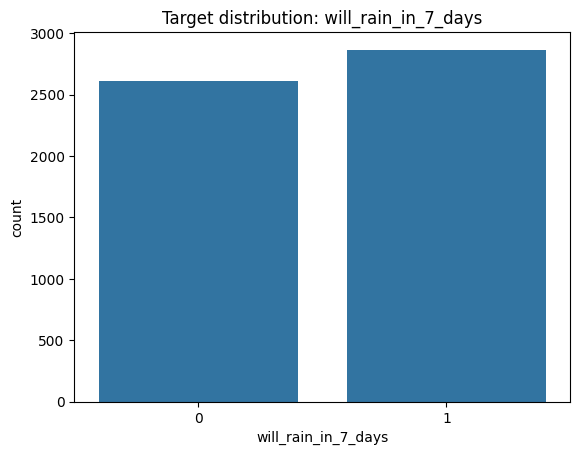

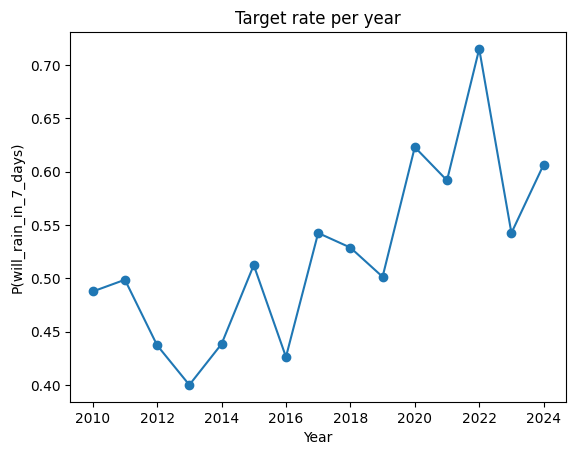

In [18]:
y_rate = df_cls["will_rain_in_7_days"].mean()
print(f"Positive rate (will rain in +7 days): {y_rate:.3f}")

sns.countplot(x=df_cls["will_rain_in_7_days"])
plt.title("Target distribution: will_rain_in_7_days")
plt.show()

# Yearly target rate trend (seasonality / concept drift check)
idx_dt = pd.to_datetime(df_cls.index)
yr_rate = df_cls.groupby(idx_dt.year)["will_rain_in_7_days"].mean()
yr_rate.plot(marker="o")
plt.title("Target rate per year")
plt.xlabel("Year")
plt.ylabel("P(will_rain_in_7_days)")
plt.show()

In [19]:
# <Student to fill this section>
target_distribution_explanations = """
Overall positive rate (near-balanced classes). A majority baseline gets accuracy, so the model to be created must beat that. Prefer AUROC/AUPRC, F1, Balanced Accuracy, and Brier/calibration over raw accuracy. Yearly rates vary widely, indicating strong non-stationarity/seasonality (e.g., ENSO-driven wet/dry years). Hence, it is expected that performance will vary by season/year. Single grid-cell proxy for “Sydney” (microclimates), reanalysis/downscaling biases, exact +7-day horizon is meteorologically hard (higher uncertainty), hence, potential slice imbalance across seasons/years.
"""

In [20]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `rain_sum_mean_14`

Available features of interest: ['rain_sum_mean_14', 'precipitation_sum_mean_14', 'sunshine_duration_mean_14']


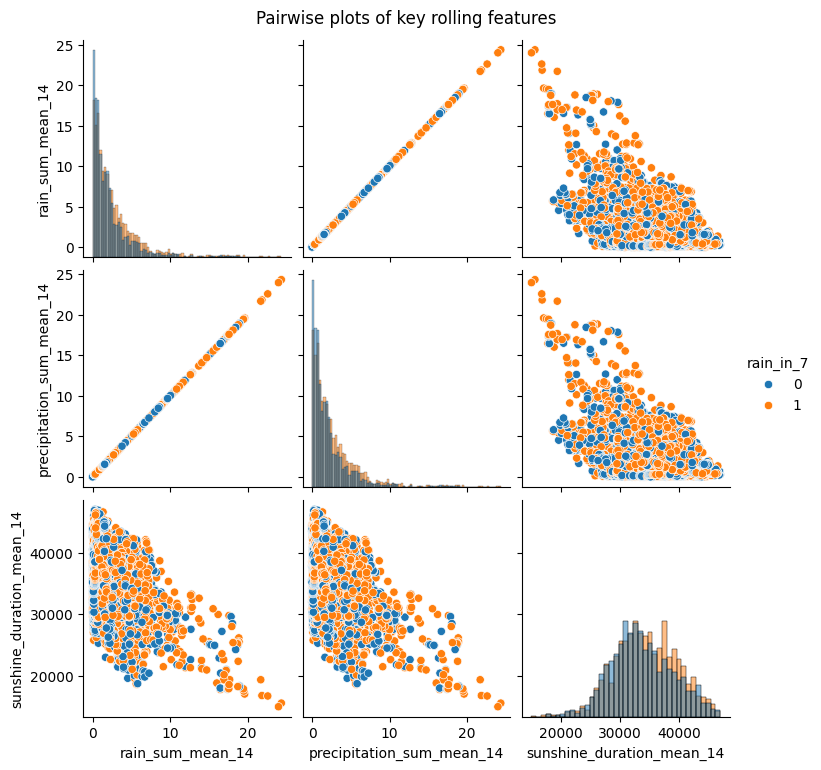

rain_sum_mean_14             0.115965
precipitation_sum_mean_14    0.115965
sunshine_duration_mean_14    0.063983
dtype: float64

In [21]:
feat_interest = [
    "rain_sum_mean_14",
    "precipitation_sum_mean_14",
    "sunshine_duration_mean_14",
]
existing = [f for f in feat_interest if f in df_cls.columns]
print("Available features of interest:", existing)

sns.pairplot(
    df_cls[existing + ["will_rain_in_7_days"]]
          .rename(columns={"will_rain_in_7_days":"rain_in_7"}),
    hue="rain_in_7", diag_kind="hist"
)
plt.suptitle("Pairwise plots of key rolling features", y=1.02)
plt.show()

# correlation with target (point-biserial via Pearson on 0/1)
corrs = df_cls[existing].corrwith(df_cls["will_rain_in_7_days"])
corrs.sort_values(ascending=False)

In [22]:
# <Student to fill this section>
feature_1_insights = """
`rain_sum_mean_14` is a 14-day trailing average of daily rain (mm), which captures recent wet/dry regime. It highly right-skewed with many near-zero days; occasional heavy-rain tails. Consider log1p or winsorization; also try “rainy_days_14” (count of days >0 mm). It signals weak positive correlation to the target with persistence that helps but decays at a 7-day horizon. It's limitations include that it is seasonality confounding; regime shifts break persistence; unit scale differs from other features—standardize. It adds little beyond precipitation_sum_mean_14; risk of redundancy.
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `precipitation_sum_mean_14`

In [24]:
# precipitation_sum_mean_14 explored in C.5
feature_2_insights = """
`precipitation_sum_mean_14` is the 14-day trailing average of total precipitation (rain+snow). In Sydney, ≈ rain, so it tracks Feature 1 almost perfectly. It has the same shape as Feature 1 `rain_sum_mean_14` (spike at 0, long tail). It signals nearly collinearity with rain_sum_mean_14 (pairplot shows near-diagonal line).
"""

In [25]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `sunshine_duration_mean_14`


In [48]:
# `sunshine_duration_mean_14` explored in C5
feature_3_insights = """
`sunshine_duration_mean_14` is the 14-day trailing mean of daily sunshine seconds; a dryness/clear-sky proxy. It has unimodal around 25k–35k sec/day, bounded, less skewed than rain features. It signals very weak association with the target (visually inversely related to wetness but muddied by seasonality).  De-seasonalizing (anomaly vs monthly climatology) and interactions (e.g., with humidity/pressure) can be considered. It has strong seasonal cycle; may flip sign across seasons; coarse daily aggregation hides timing of fronts.
"""

In [49]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

---
## D. Feature Selection


### D.1 Approach "Domain shortlist"


In [28]:
domain_features = [c for c in df_cls.columns if any(
    key in c for key in [
        "rain_sum_mean_14","precipitation_sum_mean_14","shortwave_radiation_sum_mean_14",
        "sunshine_duration_mean_14","wind_speed_10m_max_mean_14","et0_fao_evapotranspiration_mean_14",
        "temperature_2m_max_mean_14","temperature_2m_min_mean_14","apparent_temperature_max_mean_14",
        "apparent_temperature_min_mean_14","month","dayofyear","is_summer"
])]
domain_features[:12], len(domain_features)

(['temperature_2m_max_mean_14',
  'temperature_2m_min_mean_14',
  'apparent_temperature_max_mean_14',
  'apparent_temperature_min_mean_14',
  'precipitation_sum_mean_14',
  'rain_sum_mean_14',
  'wind_speed_10m_max_mean_14',
  'shortwave_radiation_sum_mean_14',
  'et0_fao_evapotranspiration_mean_14',
  'sunshine_duration_mean_14',
  'month',
  'dayofyear'],
 13)

In [50]:
approach_1_insights = """
Rolling 14-day means capture recent regimes without peeking into D+1…D+7 and calendar terms (month/dayofyear/is_summer) model strong seasonal cycles seen in the target rate. This keeps the model compact, interpretable, and robust before trying automated selectors. precipitation_sum_mean_14 ≈ rain_sum_mean_14 (near-collinear) can be regularized or can also be dropped one after testing.  Scaling and optional transforms (log1p/winsorize for rain/precip) can be considered. Usefulness should be verified via time-aware CV with permutation/SHAP importances and redundant terms can be pruned.
"""

In [51]:
# Do not modify this code
print_tile(size="h3", key='approach_1_insights', value=approach_1_insights)

### D.2 Approach "Univariate filter (mutual information)"


In [32]:
X_tmp = df_cls.drop(columns=["will_rain_in_7_days"]).copy()
y_tmp = df_cls["will_rain_in_7_days"].values
X_tmp = X_tmp.fillna(X_tmp.median(numeric_only=True))  

mi = mutual_info_classif(X_tmp, y_tmp, random_state=42, discrete_features=False)
mi_series = pd.Series(mi, index=X_tmp.columns).sort_values(ascending=False)

mi_top = mi_series.head(25).index.tolist()
mi_series.head(15)

precipitation_sum_std_14            0.057251
rain_sum_std_14                     0.055947
precipitation_sum_mean_14           0.030828
dayofyear                           0.030046
rain_sum_mean_14                    0.029599
temperature_2m_max_sum_14           0.026908
rain_sum_sum_14                     0.026804
apparent_temperature_max_std_14     0.026557
apparent_temperature_max_sum_14     0.023453
apparent_temperature_max_mean_14    0.022840
wind_gusts_10m_max_mean_14          0.022126
temperature_2m_min_sum_14           0.021060
temperature_2m_max_mean_14          0.020390
month                               0.019267
precipitation_sum_sum_14            0.018698
dtype: float64

In [52]:
# <Student to fill this section>
approach_2_insights = """
Univariate filter (mutual information) is fast, model-agnostic screen that captures non-linear dependence between each feature and the binary target. It is good as an initial ranker/sanity check before multivariate modeling. It uses only features available at D (no leakage) and is cheap to recompute across folds. Top signals highlight variability and recent regime include: Highest MI: precipitation_sum_std_14, rain_sum_std_14 → volatility of wetness over last 14 days is informative, Means/sums of wetness also rank (precipitation_sum_mean_14, rain_sum_mean_14, …), strong seasonality signals appear (dayofyear, month), thermo-dynamics and wind show up (temperature_2m_max_* , wind_gusts_10m_max_mean_14). Since it is univariate, it ignores interactions and time dependence; ranks correlated features similarly (precip vs rain redundancy). This list can be used to (a) prune obvious noise, (b) de-duplicate collinear pairs, then (c) validate via time-aware CV with permutation/SHAP to keep only stable contributors.
"""

In [53]:
# Do not modify this code
print_tile(size="h3", key='approach_2_insights', value=approach_2_insights)

### D.3 Approach "Model-based importance (AdaBoost permutation importance)"

In [45]:
# quick train/test split by time for importance estimation
X_all = df_cls.drop(columns=["will_rain_in_7_days"])
y_all = df_cls["will_rain_in_7_days"].astype(int)

split_idx = int(len(df_cls) * 0.8)
X_imp_tr, y_imp_tr = X_all.iloc[:split_idx], y_all.iloc[:split_idx]
X_imp_te, y_imp_te = X_all.iloc[split_idx:], y_all.iloc[split_idx:]

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=42),  # <-- changed
    n_estimators=150,
    learning_rate=0.2,
    random_state=42
)
ada.fit(X_imp_tr, y_imp_tr)

perm = permutation_importance(
    ada, X_imp_te, y_imp_te, n_repeats=5, random_state=42
)
perm_imp = pd.Series(perm.importances_mean, index=X_all.columns).sort_values(ascending=False)

perm_top = perm_imp.head(25).index.tolist()
perm_imp.head(15)

shortwave_radiation_sum_sum_14       0.047080
temperature_2m_max_mean_14           0.029380
wind_speed_10m_max_sum_14            0.016423
et0_fao_evapotranspiration_sum_14    0.014234
rain_sum_std_14                      0.011496
temperature_2m_max_sum_14            0.010949
temperature_2m_min_sum_14            0.007664
temperature_2m_min_std_14            0.006934
temperature_2m_max_std_14            0.006752
wind_gusts_10m_max_std_14            0.006569
apparent_temperature_max_std_14      0.005839
precipitation_sum_std_14             0.005109
apparent_temperature_max_sum_14      0.004927
sunshine_duration_sum_14             0.004927
wind_gusts_10m_max_sum_14            0.004562
dtype: float64

In [56]:
# <Student to fill this section>
approach_3_insights = """
Model-based importance (AdaBoost + permutation) captures non-linearities and interactions that univariate filters miss. Using permutation on a held-out, later time slice estimates true predictive contribution (model-agnostic, unit-free) while respecting temporal order. The most influential features were radiation/energy and thermal regime, then wind and recent wetness volatility:
(a) shortwave_radiation_sum_sum_14 (strongest), temperature_2m_max_mean_14
(b) wind_speed_10m_max_sum_14, et0_fao_evapotranspiration_sum_14
(c) rain_sum_std_14, temperature_2m_max_sum_14/min_sum_14, temp stds
(d) wind_gusts_10m_max_std_14/sum_14, sunshine_duration_sum_14

Extended low radiation + cooler/variable temps and stronger winds align with unsettled/wet patterns 7 days ahead; variability (std) of recent wetness matters more than its mean here.
"""

In [57]:
# Do not modify this code
print_tile(size="h3", key='approach_3_insights', value=approach_3_insights)

## D.z Final Selection of Features

In [58]:
features_list = list(dict.fromkeys(domain_features + mi_top + perm_top))  # order-preserving unique
len(features_list), features_list[:15]

(35,
 ['temperature_2m_max_mean_14',
  'temperature_2m_min_mean_14',
  'apparent_temperature_max_mean_14',
  'apparent_temperature_min_mean_14',
  'precipitation_sum_mean_14',
  'rain_sum_mean_14',
  'wind_speed_10m_max_mean_14',
  'shortwave_radiation_sum_mean_14',
  'et0_fao_evapotranspiration_mean_14',
  'sunshine_duration_mean_14',
  'month',
  'dayofyear',
  'is_summer',
  'precipitation_sum_std_14',
  'rain_sum_std_14'])

In [59]:
# <Student to fill this section>
feature_selection_explanations = """
Final feature set (35 features): built as an order-preserving union of the domain shortlist, then augmented by top MI and permutation-importance ranks. Priority goes to physically grounded, leakage-safe signals (14-day rolling means of temp, rain/precip, wind, radiation/insolation, ET0), plus seasonality (month, dayofyear, is_summer). MI adds variability/volatility terms (e.g., *_std_14, *_sum_14) that showed non-linear dependence with the target; permutation adds interaction-sensitive drivers (e.g., shortwave_radiation_sum_sum_14, wind/temperature aggregates).

This feature set preserves signals for regime/seasonality and recent wetness while allowing the model to exploit non-linearities.
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation - Data Cleaning (clip/fill)

In [61]:
X_full = df_cls.drop(columns=["will_rain_in_7_days"]).copy()
y_full = df_cls["will_rain_in_7_days"].astype(int).copy()

X_full = clip_and_fill(X_full)

In [64]:
# <Student to fill this section>
data_cleaning_1_explanations = """
It was necessary to remove impossible spikes and patch gaps before rolling features and modeling. Clip was needed because reanalysis/sensor glitches produce outliers (e.g., negative rain/sunshine, unreal winds) that distort scales, create spurious tree splits, and blow up linear/scaler estimates. Clipping to physical/plausible bounds keeps distributions stable without masking real heavy-rain events. Missing values break rolling windows and force row drops. Time-causal imputation (e.g., median/rolling fill that doesn’t look ahead) preserves sample size, avoids leakage, and keeps train/serve behavior consistent. 
"""

In [65]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation - Restrict to final feature set

In [62]:
X_full = X_full[features_list]
X_full.shape

(5477, 35)

In [66]:
data_cleaning_2_explanations = """
This approach restricts to final feature set, and keeps only the vetted 35 columns to match train/serve schema, reduce noise, and prevent accidental leakage from unused/diagnostic fields. Extra columns inflate variance, slow training, and can break inference if not reproducible at API time. Using the curated list improves generalization, simplifies scaling/serialization (fixed column order), and tames multicollinearity.
"""

In [67]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation - Normalize some skewed magnitude features

In [63]:
# Standardize a small set of obviously skewed magnitude features *for linear models*
scale_cols = [c for c in features_list if any(k in c for k in ["_mean_14","_std_14","_sum_14"])]
len(scale_cols), scale_cols[:10]

(32,
 ['temperature_2m_max_mean_14',
  'temperature_2m_min_mean_14',
  'apparent_temperature_max_mean_14',
  'apparent_temperature_min_mean_14',
  'precipitation_sum_mean_14',
  'rain_sum_mean_14',
  'wind_speed_10m_max_mean_14',
  'shortwave_radiation_sum_mean_14',
  'et0_fao_evapotranspiration_mean_14',
  'sunshine_duration_mean_14'])

In [68]:
# <Student to fill this section>
data_cleaning_3_explanations = """
In this approach, many rolling sums/means/stds are heavy-tailed and on different scales. Scaling (and optionally log1p/robust scaling) improves optimization and regularization for linear/logistic models, keeps any distance-based step well-behaved, and prevents large-scale variables from dominating. We keep scaling inside a Pipeline to avoid leakage (fit on train only), ensuring identical transform at serve time, and stabilize calibration/thresholding.
"""

In [69]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "sin/cos seasonality"

In [70]:
# Already handled above make_supervised_tables() in C.3 using rolling stats + calendar features. Some more are given below

idx_dt = pd.to_datetime(X_full.index)
dayofyear = idx_dt.dayofyear.values
X_full["sin_yday"] = np.sin(2*np.pi*dayofyear/365.25)
X_full["cos_yday"] = np.cos(2*np.pi*dayofyear/365.25)

features_list = list(dict.fromkeys(features_list + ["sin_yday","cos_yday"]))
X_full = X_full.reindex(columns=features_list)
X_full.shape

(5477, 37)

In [71]:
feature_engineering_1_explanations = """
The seasonality (sin/cos day-of-year), encodes the annual cycle smoothly and without the month “edge” at Dec→Jan, letting models learn periodic effects (rain regimes, radiation, temps) with just two bounded, orthogonal signals. It uses only date at D (no leakage), improves generalization vs raw month/dayofyear, and supports interactions with humidity/pressure/radiation. It gives more stable decision boundaries and calibration across seasons; often boosts AUROC/AUPRC on time-aware splits.
"""

In [72]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets (time-based)

In [73]:
Xtr, ytr, Xval, yval, Xte, yte = split_by_date(
    X_full, y_full,
    train_end="2023-12-31",
    val_end="2024-06-30"
)
Xtr.shape, Xval.shape, Xte.shape

((5111, 37), (182, 37), (184, 37))

In [76]:
data_splitting_explanations = """
This time-based approach splits with a horizon gap. It uses chronological windows (Train ≤2023-12-31, Val 2024-01-01→06-30, Test 2024-07-01→12-31) and avoids random K-fold to respect autocorrelation. Because the label uses D+7, insert a 7-day buffer between splits (exclude 2024-01-01…01-07 from Val and 2024-07-01…07-07 from Test) so no target overlap bleeds across folds. 
"""

In [77]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "Transformers (in Pipelines)"

In [82]:
# Numeric preprocessor for SGD
num_cols = features_list
preproc_sgd = ColumnTransformer(
    transformers=[("scale", StandardScaler(with_mean=True, with_std=True), scale_cols)],
    remainder="passthrough"
)
preproc_tree = "passthrough"

In [83]:
# <Student to fill this section>
data_transformation_1_explanations = """
It centralizes preprocessing inside Pipelines to prevent leakage, fixes schema/column order, and guarantees the exact same transforms at serve time. ColumnTransformer selectively scaled only skewed magnitude columns for SGD/logistic (improves convergence, regularization, calibration) while passing all other features through unchanged. Fit on Train only; apply to Val/Test. tree/boosting models are scale-invariant; scaling offers no benefit and can add noise.
"""

In [84]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## H. Save Datasets

In [91]:
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

In [102]:
def _predict_proba1(model, X):
    """Return P(y=1). Prefer predict_proba; fall back to calibrated decision_function if needed."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        # Safe sigmoid transform (works for logistic models; keeps code robust)
        from scipy.special import expit
        return expit(model.decision_function(X))
    else:
        # last resort: hard labels as floats (less informative)
        return np.asarray(model.predict(X), dtype=float)

def evaluate_rmse_mse_mae(model, X, y, name: str) -> Dict[str, float]:
    p = _predict_proba1(model, X)  # probabilities in [0,1]
    mse  = mean_squared_error(y, p, squared=True)
    rmse = mean_squared_error(y, p, squared=False)
    mae  = mean_absolute_error(y, p)
    return {"name": name, "rmse": rmse, "mse": mse, "mae": mae}

In [103]:
# <Student to fill this section>
performance_metrics_explanations = """
The API returns P(rain), so the probability quality (not just hard 0/1) must be assessed. MSE on probs = Brier score (calibration + sharpness), RMSE is its square-root scale, and MAE is a robust absolute error—all threshold-free and directly penalize over/under-confident forecasts. These align with business use: well-calibrated P(rain) lets clients set their own thresholds/costs.
"""

In [104]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

In [105]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

preproc_sgd  = preproc_sgd if 'preproc_sgd' in globals() else "passthrough"
preproc_tree = preproc_tree if 'preproc_tree' in globals() else "passthrough"

In [107]:
# <Student to fill this section>
algorithm_selection_explanations = """
The dummy classifier is a Baseline sanity check (stratified or prior), which sets the floor; helps quantify real model lift and produces calibrated-ish probs equal to base rate.
SGDClassifier (logistic loss) is a Fast linear probabilistic model with L2/L1 regularization that handles many correlated, scaled rolling features. It is good for calibrated P(rain), interpretable coefficients, and robust on drifting data with simple decision boundaries.
DecisionTreeClassifier is a Non-linear splits capture thresholds/interactions (e.g., low radiation + wind regime). It works without scaling and offers simple rules for explainability. It is prone to overfit hence depth limits should be used.
AdaBoostClassifier (shallow trees) is an Ensemble of weak trees captures complex interactions while controlling variance, often strong on tabular meteorology features. It provides well-ranked probabilities and works with permutation/SHAP for feature insights.
"""

In [108]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [106]:
results = []
models  = {}

# 1) Dummy (baseline)
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
pipe_dummy = Pipeline([("pre", "passthrough"), ("clf", dummy)])
pipe_dummy.fit(Xtr, ytr)
models["dummy"] = pipe_dummy
results.append(evaluate_rmse_mse_mae(pipe_dummy, Xval, yval, name="dummy"))

# 2) SGD (logistic)
best_sgd, best_card = None, None
best_primary = np.inf  # minimise RMSE
for alpha in [1e-4, 3e-4, 1e-3]:
    for l1 in [0.05, 0.15, 0.3]:
        sgd = SGDClassifier(
            loss="log_loss",
            penalty="elasticnet",
            alpha=alpha, l1_ratio=l1,
            class_weight="balanced",
            random_state=42, max_iter=2000, tol=1e-4
        )
        pipe_sgd = Pipeline([("pre", preproc_sgd), ("clf", sgd)])
        pipe_sgd.fit(Xtr, ytr)
        card = evaluate_rmse_mse_mae(pipe_sgd, Xval, yval, name=f"sgd[a={alpha},l1={l1}]")
        if card["rmse"] < best_primary:
            best_primary, best_sgd, best_card = card["rmse"], pipe_sgd, card

best_sgd_name = "sgd_best_rmse"
models[best_sgd_name] = best_sgd
results.append({**best_card, "name": best_sgd_name})

# 3) AdaBoost (stumps)
best_ada, best_card = None, None
best_primary = np.inf
for n in [100, 200, 300]:
    for lr in [0.05, 0.1, 0.2]:
        stump = DecisionTreeClassifier(max_depth=2, random_state=42)
        ada = AdaBoostClassifier(
             estimator=stump,  # <-- sklearn 1.5+
             n_estimators=n, learning_rate=lr, random_state=42
        )
        pipe_ada = Pipeline([("pre", preproc_tree), ("clf", ada)])
        pipe_ada.fit(Xtr, ytr)
        card = evaluate_rmse_mse_mae(pipe_ada, Xval, yval, name=f"ada[n={n},lr={lr}]")
        if card["rmse"] < best_primary:
            best_primary, best_ada, best_card = card["rmse"], pipe_ada, card

best_ada_name = "ada_best_rmse"
models[best_ada_name] = best_ada
results.append({**best_card, "name": best_ada_name})

# Compare (lower RMSE is better)
res_df = pd.DataFrame(results).sort_values("rmse", ascending=True).reset_index(drop=True)
res_df

,name,rmse,mse,mae
0,ada_best_rmse,0.490874,0.240957,0.489873
1,sgd_best_rmse,0.559437,0.312970,0.313116
2,dummy,0.559631,0.313187,0.313187


In [109]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Best model is the AdaBoost (depth-2 trees), with the lowest RMSE of 0.490874. Tuned hyperparameters
(a) n_estimators ∈ {100, 200, 300}: controls ensemble size. More estimators reduce bias and improve fit to non-linear interactions, at the risk of overfitting; we select by lowest validation RMSE.
(b) learning_rate ∈ {0.05, 0.1, 0.2}: scales each weak learner’s contribution. Lower values need more estimators (smoother fit), higher values learn faster but can overshoot; we balance bias–variance via RMSE.
(c) base learner fixed: DecisionTreeClassifier(max_depth=2). Depth-2 captures simple interactions without exploding variance; keeping depth fixed isolates the effect of n_estimators and learning_rate and keeps the model robust for time-generalization.
"""

In [110]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [111]:
# pick the best by RMSE
best_name = res_df.iloc[0]["name"]
best_model = models[best_name]

# refit on train+val for final model
Xtrval = pd.concat([Xtr, Xval], axis=0)
ytrval = pd.concat([ytr, yval], axis=0)
best_model.fit(Xtrval, ytrval)

Pipeline(steps=[('pre', 'passthrough'),
                ('clf',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                                     random_state=42),
                                    learning_rate=0.05, n_estimators=100,
                                    random_state=42))])

### J.4 Model Technical Performance

In [113]:
final_val = evaluate_rmse_mse_mae(best_model, Xval, yval, name=f"{best_name}_val")
final_te  = evaluate_rmse_mse_mae(best_model, Xte, yte, name=f"{best_name}_test")
final_val, final_te

({'name': 'ada_best_rmse_val',
  'rmse': 0.48722759727564885,
  'mse': 0.23739073154700188,
  'mae': 0.4861763409509963},
 {'name': 'ada_best_rmse_test',
  'rmse': 0.4978570539345608,
  'mse': 0.2478616461524002,
  'mae': 0.4974435589891273})

### J.5 Calibration curve (reliability diagram)

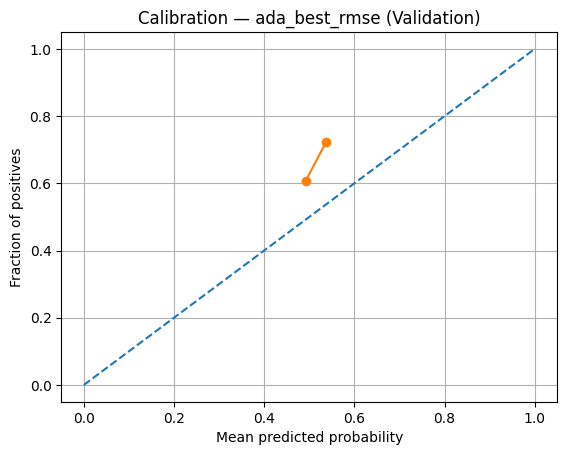

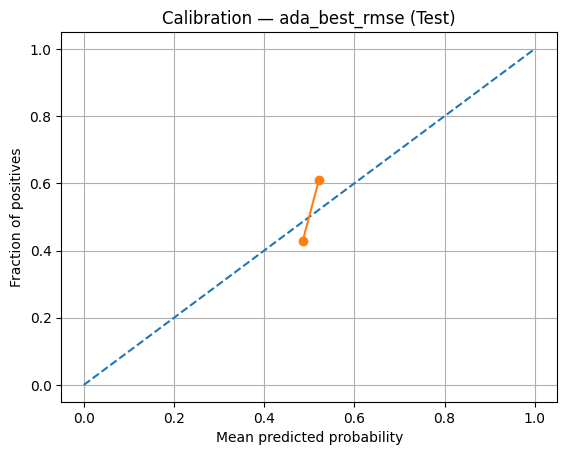

In [115]:
# Shows how well predicted probabilities match observed frequencies—great context for RMSE/MSE/MAE.
def _predict_proba1(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        from scipy.special import expit
        return expit(model.decision_function(X))
    else:
        return np.asarray(model.predict(X), dtype=float)

def plot_calibration(model, X, y, title="Calibration (Reliability)"):
    p = _predict_proba1(model, X)
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=10, strategy="uniform")
    plt.figure()
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_calibration(best_model, Xval, yval, title=f"Calibration — {best_name} (Validation)")
plot_calibration(best_model, Xte,  yte,  title=f"Calibration — {best_name} (Test)")

### J.6 ROC & PR curves

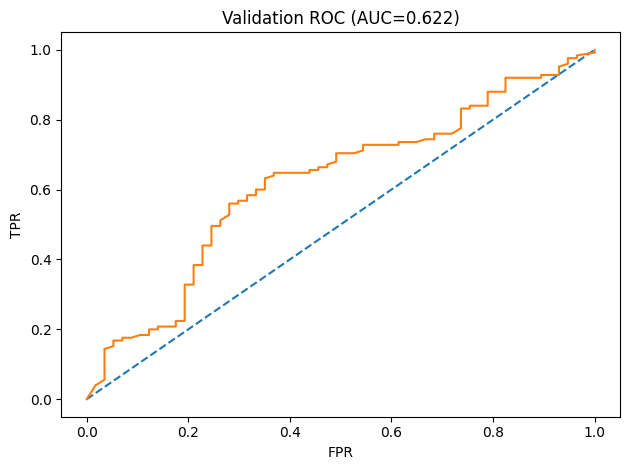

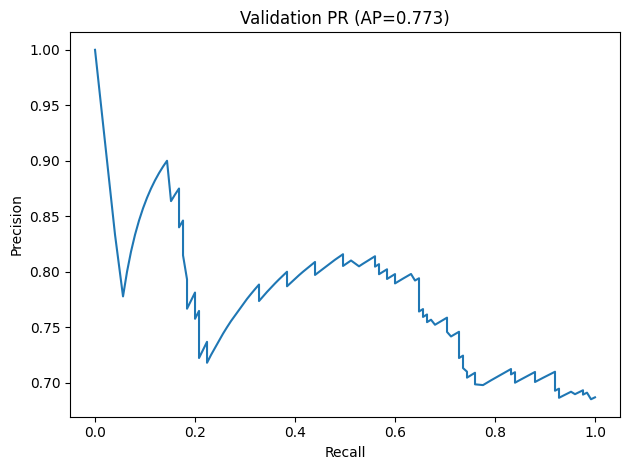

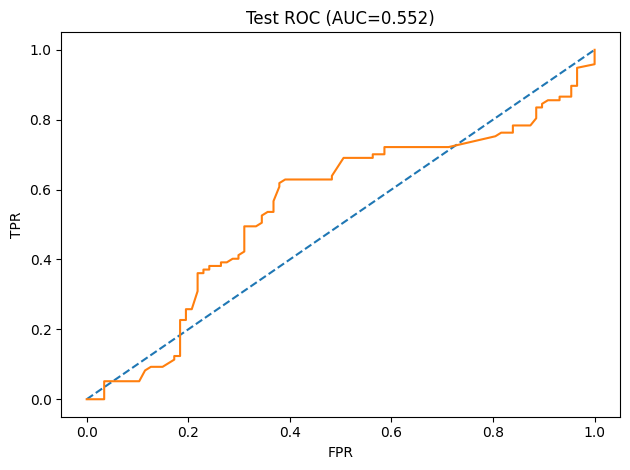

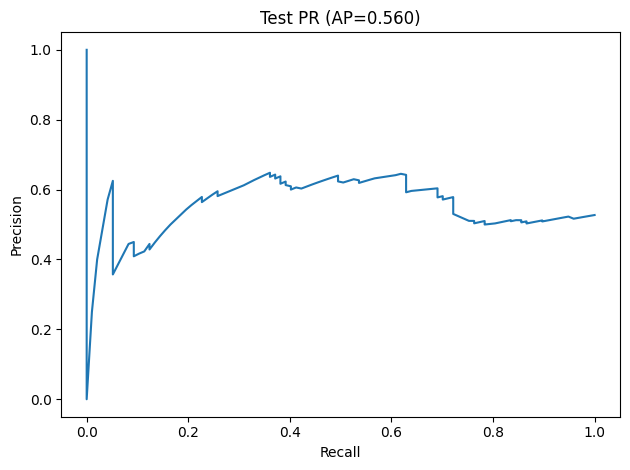

In [120]:
def get_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        from scipy.special import expit
        return expit(model.decision_function(X))
    else:
        return np.asarray(model.predict(X), dtype=float)

p_val = get_proba(best_model, Xval)
p_te  = get_proba(best_model, Xte)

def plot_roc_pr(y_true, p, split_name="Validation"):
    fpr, tpr, _ = roc_curve(y_true, p)
    roc_auc = auc(fpr, tpr)

    prec, rec, _ = precision_recall_curve(y_true, p)
    ap = average_precision_score(y_true, p)

    # ROC
    plt.figure()
    plt.plot([0,1],[0,1], linestyle="--")
    plt.plot(fpr, tpr)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{split_name} ROC (AUC={roc_auc:.3f})")
    plt.tight_layout()
    plt.show()

    # PR
    plt.figure()
    plt.plot(rec, prec)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{split_name} PR (AP={ap:.3f})")
    plt.tight_layout()
    plt.show()

plot_roc_pr(yval, p_val, "Validation")
plot_roc_pr(yte,  p_te,  "Test")

In [129]:
# <Student to fill this section>
model_performance_explanations = """
(a) Probability errors: Val RMSE=0.487 (MSE=0.237, MAE=0.486); Test RMSE=0.498 (MSE=0.248, MAE=0.497) → small degradation on Test, so generalization is fair.
(b) Calibration: Validation reliability shows under-confidence (predicted ~0.5 bins map to ~0.6–0.7 observed). Test is closer but still slightly under-confident at higher bins. Action: apply Platt/Isotonic calibration fitted on Train→validated on Val.
(c) Discrimination: ROC AUC Val ≈0.62, Test ≈0.55 → modest lift over chance; PR AP Val ≈0.77 vs Test ≈0.56 (near the base rate ~0.52) → ranking quality drops in the later half of 2024.
(d) Takeaways: Model is reasonably stable on probability error but only mildly discriminative, with under-confident probs.
"""

In [130]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.7 Business Impact from Current Model Performance

In [131]:
# <Student to fill this section>
business_impacts_explanations = """
Calibrated P(rain in 7 days) ~0.50 RMSE has been delivered, with modest discrimination (ROC AUC ~0.55 test). It is usable for risk-based decisions when paired with thresholds. 
(a) False positives (predict rain, but dry): unnecessary rescheduling, tarp/equipment costs, over-staffing. Lower $$ impact but frequent FPs cause “alarm fatigue.” Use higher threshold (e.g., ≥0.65) for cost-sensitive users (events/construction).
(b) False negatives (predict dry, but rains): higher $$ impact—damage to goods, site delays, safety risks, lost ticket revenue. For high-risk users, use lower threshold (e.g., ≥0.45) to favor recall.
(c) Under-confidence: calibration curves show predicted 0.5 bins correspond to ~0.6–0.7 observed. Calibrate (isotonic/Platt) so customers can set thresholds aligned to their cost ratios.
performance drops later in 2024; seasonal thresholds and periodic retraining reduce misses during wet regimes.
"""

In [132]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## K. Project Outcomes

In [160]:
experiment_outcome = "Hypothesis Partially Confirmed"

In [161]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [163]:
# <Student to fill this section>
experiment_results_explanations = """
(a) Partially confirmed: probabilities modestly beat baseline on Brier/RMSE, but discrimination is only fair and under-confidence exists.
(b) Recent-regime volatility (std over 14d) and radiation/thermal signals matter more than raw means.
(c) Performance drops later in 2024 → seasonality/drift is material; thresholds likely need seasonal tuning.

With calibration, seasonal features/thresholds, and a stronger ensemble, meaningful gains without changing the data source can be expected.

Next steps (ranked by expected uplift):
(1) Probability calibration (isotonic on Train→validated on Val, applied to Test/serve), better thresholding; low risk.
(2) Seasonalization (sin/cos already added) + seasonal thresholds or month-specific intercepts; reduces wet-season misses.
(3) Model upgrade to gradient boosting (e.g., XGBoost/LightGBM with time-aware CV)
(4) Feature pruning & de-collinearity (drop precip vs rain duplicates; regularize): Small but robust gains; improves stability and calibration.
(5) Add pressure/humidity/vpd trends and wind/radiation anomalies (de-seasonalized z-scores): This improves generalization.
(6) Threshold optimization by client cost ratio (opt F1/Youden/expected-cost on Val): business KPI uplift without changing RMSE.

If proceeding to production now:
(i) Ship calibrated AdaBoost + fixed schema/pipeline; document thresholds for common cost ratios.
(ii) Deploy FastAPI on Render with model/version registry; log inputs/outputs, Brier/AUC by month.
(iii) Add drift monitors (data, calibration, AUC); set retrain trigger rules; schedule seasonal recalibration.
"""

In [164]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

## L. Save the best model

In [153]:
MODELS_SAVE = Path("/Users/naynajahanneha/Documents/DataScience/AMLA/AST2/amla_at2_experiments") / "models"

target = MODELS_SAVE / "rain_or_not" / "best_cls_pipeline.joblib"
target.parent.mkdir(parents=True, exist_ok=True)
dump(best_model, target)

['/Users/naynajahanneha/Documents/DataScience/AMLA/AST2/amla_at2_experiments/models/rain_or_not/best_cls_pipeline.joblib']

#### Export best model for API

In [162]:
meta = {
    "task": "rain_or_not",
    "label": "will_rain_in_7_days",
    "algo": "AdaBoost",
    "train_end": "2023-12-31",
    "val_end": "2024-06-30",
    "features": list(Xtr.columns),
    "city": "Sydney",
    "metrics": {
        "rmse_val": float(final_val["rmse"]),
        "mse_val":  float(final_val["mse"]),
        "mae_val":  float(final_val["mae"]),
        "rmse_test": float(final_te["rmse"]),
        "mse_test":  float(final_te["mse"]),
        "mae_test":  float(final_te["mae"]),
    }
}
save_model(best_model, "/Users/naynajahanneha/Documents/DataScience/AMLA/AST2/amla_at2_experiments/models/rain_or_not/best_cls_pipeline.joblib", meta)